# ECON 5140: Applied Econometrics
## Lesson 13 demo — Modern ML for causal inference

This notebook complements **Lesson 13** (ML for causal inference, DML, double robustness, meta-learners). We use **real data** from the **National Supported Work (NSW) demonstration**, **Dehejia–Wahba subsample** (experimental random assignment).

**References (economics / methods):**
- LaLonde (1986), *American Economic Review* — evaluation of training programs.
- Dehejia & Wahba (1999) — covariate balance and the NSW subsample used here.
- Chernozhukov et al. (2018), *Econometrica* — double/debiased machine learning.
- Medium / practitioners: many tutorials use this same NSW file when explaining causal ML (e.g. meta-learners, `econml` walkthroughs).

**Data:** `data/nsw_dw.csv` (columns from the Dehejia–Wahba Stata file; source: [xuyiqing/lalonde](https://github.com/xuyiqing/lalonde) on GitHub).  
**Outcome:** `re78` (real earnings in 1978). **Treatment:** `treat` (NSW job-training offer / participation).

## Setup


In [10]:
from __future__ import annotations

from pathlib import Path

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm

warnings.filterwarnings("ignore")
np.random.seed(5140)


## Load the Dehejia–Wahba NSW experimental sample


In [11]:
DATA = Path("data/nsw_dw.csv")
df = pd.read_csv(DATA)
# Drop label column; keep pre-treatment covariates + outcome
df = df.drop(columns=["data_id"], errors="ignore")
y_col, d_col = "re78", "treat"
cov_cols = [c for c in df.columns if c not in (y_col, d_col)]
Y = df[y_col].astype(float).values
D = df[d_col].astype(float).values
X = df[cov_cols].astype(float).values
n = len(df)
print(f"n = {n}, treated = {int(D.sum())}, control = {int(n - D.sum())}")
print("Covariates:", cov_cols)
print(df.head())


n = 445, treated = 185, control = 260
Covariates: ['age', 'education', 'black', 'hispanic', 'married', 'nodegree', 're74', 're75']
   treat   age  education  black  hispanic  married  nodegree  re74  re75  \
0    1.0  37.0       11.0    1.0       0.0      1.0       1.0   0.0   0.0   
1    1.0  22.0        9.0    0.0       1.0      0.0       1.0   0.0   0.0   
2    1.0  30.0       12.0    1.0       0.0      0.0       0.0   0.0   0.0   
3    1.0  27.0       11.0    1.0       0.0      0.0       1.0   0.0   0.0   
4    1.0  33.0        8.0    1.0       0.0      0.0       1.0   0.0   0.0   

         re78  
0   9930.0460  
1   3595.8940  
2  24909.4500  
3   7506.1460  
4    289.7899  


## Benchmarks: naive ATE and linear regression

Naive difference in mean `re78` equals the experimental ATE here (RCT). OLS with covariates should be similar if balance is good.


In [12]:
naive = Y[D == 1].mean() - Y[D == 0].mean()
X_df = sm.add_constant(pd.DataFrame(X, columns=cov_cols))
X_df["treat"] = D
ols = sm.OLS(Y, X_df).fit()
ate_ols = ols.params["treat"]
print(f"Naive ATE (mean difference):     {naive:,.2f}")
print(f"OLS ATE (linear, controls):      {ate_ols:,.2f}")
print(ols.summary().tables[1])


Naive ATE (mean difference):     1,794.34
OLS ATE (linear, controls):      1,676.34
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        785.0615   3374.969      0.233      0.816   -5848.211    7418.334
age           55.3167     45.284      1.222      0.223     -33.686     144.319
education    395.7343    227.415      1.740      0.083     -51.234     842.703
black      -2159.5221   1169.036     -1.847      0.065   -4457.183     138.139
hispanic     164.0327   1549.457      0.106      0.916   -2881.320    3209.386
married     -138.7252    879.728     -0.158      0.875   -1867.771    1590.321
nodegree     -70.6807   1004.387     -0.070      0.944   -2044.736    1903.374
re74           0.0821      0.077      1.061      0.289      -0.070       0.234
re75           0.0528      0.135      0.389      0.697      -0.214       0.319
treat       1676.3426    638.682      2.625    

## Partially linear DML (PLR) — Chernozhukov et al. (2018)

We estimate the **partially linear model** $Y = \\theta D + g(X) + U$ with **binary** $D$, using **double machine learning**:

1. **Nuisance functions** (flexible ML, estimated with **cross-fitting** so each observation is not used to fit its own nuisance):  
   $\\ell(X) \\approx E[Y\\mid X]$ and $m(X) \\approx E[D\\mid X]$.
2. **Orthogonal score** for $\\theta$ so first-order bias from estimating $\\ell, m$ is removed (see the paper).
3. Implementation: **`DoubleMLPLR`** from the Python [`doubleml`](https://docs.doubleml.org/) package (required — install before running).

This is **DML** in the sense of the lecture — **not** the same object as naive “predict $Y$ with ML and call it causal.”


In [13]:
from doubleml import DoubleMLData, DoubleMLPLR
from sklearn.ensemble import RandomForestClassifier

dml_df = df.copy()
dml_data = DoubleMLData(dml_df, y_col="re78", d_cols="treat", x_cols=cov_cols)

ml_l = RandomForestRegressor(
    n_estimators=400, max_depth=8, random_state=5140, n_jobs=-1
)
ml_m = RandomForestClassifier(
    n_estimators=400, max_depth=8, random_state=5141, n_jobs=-1
)

dml_plr = DoubleMLPLR(dml_data, ml_l, ml_m, n_folds=5)
dml_plr.fit()
print(dml_plr.summary)
ate_dml = float(dml_plr.coef[0])
se_dml = float(dml_plr.se[0])
print(f"\nDML PLR ATE (treat): {ate_dml:,.2f}  (SE ≈ {se_dml:,.2f})")


              coef     std err         t     P>|t|       2.5 %       97.5 %
treat  1804.086506  680.202512  2.652279  0.007995  470.914081  3137.258932

DML PLR ATE (treat): 1,804.09  (SE ≈ 680.20)


**Connection to the slides:** Cross-fitting + orthogonal scores are what let you use **random forests** (or lasso, nets, …) for $\\ell$ and $m$ while still targeting a **low-dimensional** causal parameter $\\theta$ with valid inference.

**R-learner (Lecture 13):** For **constant** $\\tau$, the same “remove $X$ with ML, then use residual variation in $D$” idea is closely related to the **second stage** of PLR-DML; `doubleml` implements the full Chernozhukov et al. procedure including standard errors.


## Cross-fitted AIPW (doubly robust)

**AIPW** is another **doubly robust / orthogonal** estimator (related to DML and discussed in your slides). We implement **cross-fitted** nuisance estimates for $\\mu_1(x), \\mu_0(x), e(x)=P(D=1\\mid X)$ and average the **doubly robust score** (not the same estimating equation as PLR-DML, but same *family* of ideas).

**Score (one observation):**
\[
\hat\psi_i = \hat\mu_1(X_i) - \hat\mu_0(X_i)
+ \frac{D_i (Y_i - \hat\mu_1(X_i))}{\hat e(X_i)}
- \frac{(1-D_i)(Y_i - \hat\mu_0(X_i))}{1-\hat e(X_i)}
\]
Propensities are clipped away from 0 and 1 for stability.


In [14]:
def cross_fit_aipw(X, Y, D, n_splits: int = 5, seed: int = 5140, clip: tuple[float, float] = (0.05, 0.95)):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    n = len(Y)
    mu1 = np.zeros(n)
    mu0 = np.zeros(n)
    ehat = np.zeros(n)
    for tr, te in kf.split(np.arange(n)):
        X_tr, y_tr, d_tr = X[tr], Y[tr], D[tr]
        t1, t0 = d_tr == 1, d_tr == 0
        m1 = RandomForestRegressor(n_estimators=400, max_depth=8, random_state=seed, n_jobs=-1)
        m0 = RandomForestRegressor(n_estimators=400, max_depth=8, random_state=seed + 1, n_jobs=-1)
        m1.fit(X_tr[t1], y_tr[t1])
        m0.fit(X_tr[t0], y_tr[t0])
        scaler = StandardScaler()
        Xs_tr = scaler.fit_transform(X_tr)
        Xs_te = scaler.transform(X[te])
        logit = LogisticRegression(max_iter=2000, random_state=seed)
        logit.fit(Xs_tr, d_tr)
        mu1[te] = m1.predict(X[te])
        mu0[te] = m0.predict(X[te])
        ehat[te] = logit.predict_proba(Xs_te)[:, 1]
    ehat = np.clip(ehat, clip[0], clip[1])
    psi = (mu1 - mu0) + D * (Y - mu1) / ehat - (1 - D) * (Y - mu0) / (1 - ehat)
    ate = float(np.mean(psi))
    B = 400
    rng = np.random.default_rng(seed)
    boots = []
    for _ in range(B):
        idx = rng.integers(0, n, size=n)
        boots.append(np.mean(psi[idx]))
    se = float(np.std(boots, ddof=1))
    return ate, se, psi, mu1, mu0, ehat

ate_aipw, se_aipw, psi, _, _, _ = cross_fit_aipw(X, Y, D)
print(f"Cross-fitted AIPW ATE: {ate_aipw:,.2f}  (bootstrap SE ≈ {se_aipw:,.2f})")


Cross-fitted AIPW ATE: 1,647.16  (bootstrap SE ≈ 733.71)


## Meta-learners (S- and T-learners)

After **orthogonal / DML-style** estimators, the lecture turns to **meta-learners** for **heterogeneous** effects: prediction-based ways to build $\\hat\\tau(x)$. Here we report the **sample average** of estimated CATEs as an ATE-style summary.

**S-learner:** one model for $Y$ given $(X, D)$. **T-learner:** separate models for treated vs control. Random forests as the flexible learner.


In [15]:
# S-learner: Y ~ (X, D)
XD = np.column_stack([X, D])
rf_s = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=5140, n_jobs=-1)
rf_s.fit(XD, Y)
X1 = np.column_stack([X, np.ones(n)])
X0 = np.column_stack([X, np.zeros(n)])
tau_s = rf_s.predict(X1) - rf_s.predict(X0)
ate_s = float(np.mean(tau_s))

# T-learner
rf1 = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=5141, n_jobs=-1)
rf0 = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=5142, n_jobs=-1)
rf1.fit(X[D == 1], Y[D == 1])
rf0.fit(X[D == 0], Y[D == 0])
tau_t = rf1.predict(X) - rf0.predict(X)
ate_t = float(np.mean(tau_t))

print(f"S-learner (avg CATE):  {ate_s:,.2f}")
print(f"T-learner (avg CATE):  {ate_t:,.2f}")


S-learner (avg CATE):  1,164.10
T-learner (avg CATE):  1,792.93


## Summary figure: distribution of implied CATEs (T-learner)


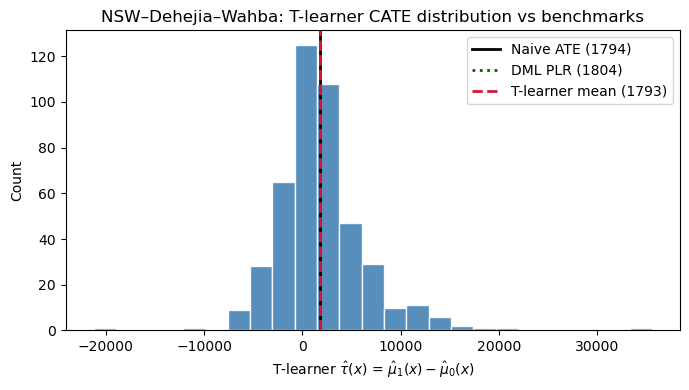

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(tau_t, bins=25, color="steelblue", edgecolor="white", alpha=0.9)
ax.axvline(naive, color="black", lw=2, label=f"Naive ATE ({naive:.0f})")
ax.axvline(ate_dml, color="darkgreen", lw=2, ls=":", label=f"DML PLR ({ate_dml:.0f})")
ax.axvline(ate_t, color="crimson", ls="--", lw=2, label=f"T-learner mean ({ate_t:.0f})")
ax.set_xlabel(r"T-learner $\hat\tau(x)$ = $\hat\mu_1(x)-\hat\mu_0(x)$")
ax.set_ylabel("Count")
ax.legend()
ax.set_title("NSW–Dehejia–Wahba: T-learner CATE distribution vs benchmarks")
plt.tight_layout()
plt.show()


## Summary table


In [17]:
summary = pd.DataFrame(
    [
        ("Naive (RCT difference in means)", naive, np.nan),
        ("OLS + controls", ate_ols, float(ols.bse["treat"])),
        ("DML PLR (DoubleML)", ate_dml, se_dml),
        ("Cross-fitted AIPW", ate_aipw, se_aipw),
        ("S-learner (RF, mean CATE)", ate_s, np.nan),
        ("T-learner (RF, mean CATE)", ate_t, np.nan),
    ],
    columns=["Estimator", "Point", "SE"],
)
print(summary.to_string(index=False))


                      Estimator       Point         SE
Naive (RCT difference in means) 1794.342404        NaN
                 OLS + controls 1676.342644 638.682016
             DML PLR (DoubleML) 1804.086506 680.202512
              Cross-fitted AIPW 1647.159802 733.708333
      S-learner (RF, mean CATE) 1164.095754        NaN
      T-learner (RF, mean CATE) 1792.926375        NaN


### Interpretation of the table (Dehejia–Wahba **experimental** subsample)

**Units:** all “Point” estimates are **dollars of 1978 earnings** (`re78`): the average effect of NSW participation on annual earnings for this sample (ATE of `treat` on `re78`).

**What each row is doing (intuition):**
- **Naive (RCT difference in means):** average `re78` for treated minus average for controls. Under **random assignment**, this is the **clean, design-based** estimator of the ATE — no covariates needed for **identification**.
- **OLS + controls:** same treatment coefficient from a **linear** model adding pre-treatment $X$. In an RCT it still targets the ATE, but it **reweights** toward a regression-adjusted comparison; with finite $n$, the coefficient can differ slightly from the raw difference (here ~\$118 lower than naive).
- **DML PLR:** estimates the coefficient $\theta$ in $Y = \theta D + g(X) + U$ using **cross-fitted** ML for nuisances and an **orthogonal** score. Here $\\theta$ should match the experimental ATE; your estimate (~\$1,804) is **very close** to naive (~\$1,794). **SE** comes from `doubleml` (asymptotic theory).
- **Cross-fitted AIPW:** a **different** doubly robust formula (outcome regression + inverse-probability pieces). It should also estimate the ATE; with **flexible** RF/logit nuisances, finite-sample values can differ from PLR (~\$1,647 here).
- **S-learner:** one RF for $Y(X, D)$. The **average** of $\hat{\mu_(X,1)} - \hat{mu(X,0)}$ often **undershoots** the true effect because the forest can **down-weight** the treatment feature (regularization / prediction loss), as in the lecture — **not** evidence that the true ATE is ~\$1,164.
- **T-learner:** separate RFs for treated and control; mean of $\hat{\mu_1(X)} - \hat{\mu_0(X)}$ is **close to naive** here (~\$1,793), which is what we expect when both arms are well estimated.

**Which is “better” here?**  
For this **RCT**, **no estimator “beats” randomization for credibility** — the **naive** difference is the right **benchmark**. Among the rest: **T-learner** and **DML** are **numerically aligned** with that benchmark; **OLS** is a standard linear alternative; **AIPW** is a bit lower in this draw (nuisance + bootstrap noise). **S-learner** is the **outlier on the low side** and illustrates why meta-learners are **not** automatically preferred for ATE. In **observational** data (where the lecture’s methods matter most), **DML / AIPW** are attractive because they combine **flexible** $X$ adjustment with **orthogonal** scores — not because they would “correct” a randomized experiment.
